In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
import io

# Обучающие данные

### Общее описание

In [40]:
# train_data = pd.read_csv("../data/train.csv", index_col=0)
def download_from_drive(file_id):
    url = f"https://drive.google.com/uc?export=download&id={file_id}"
    response = requests.get(url)
    return pd.read_csv(io.StringIO(response.text), index_col=0)

print("Загрузка данных...")
train = download_from_drive("1LLb5yFWq21E08y5EJO5bsxIbWoq-XCPf")
test = download_from_drive("1RrDUHkcouYBtaJ74Ary6NNptQZD49txv")
print("Загрузка завершена")

Загрузка данных...
Загрузка завершена


In [4]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.2 MB


In [5]:
train_data.head(5)

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
index,,,,,,,,,,,,,,,,,,,,,
0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,...,1,0,0,0,0,0,0,0,0,0
1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,...,0,1,0,0,0,0,0,0,0,0
2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,315.457,...,0,0,0,0,0,0,0,0,0,0
3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,439.375,...,0,0,1,0,0,0,0,0,0,0
4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,151.253,...,0,0,0,0,0,0,0,0,0,0


In [6]:
train_data.columns

Index(['IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex', 'MaxEStateIndex',
       'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='str', length=213)

In [7]:
target = ['IC50, mM', 'CC50, mM', 'SI']

In [8]:
train_data.shape

(751, 213)

### В 2 строках отсутствуют значения

In [9]:
null_df = pd.DataFrame(train_data.isna().sum(), columns=["nulls"])
null_df[null_df["nulls"] > 0]

,nulls
MaxPartialCharge,2
MinPartialCharge,2
MaxAbsPartialCharge,2
MinAbsPartialCharge,2
BCUT2D_MWHI,2
BCUT2D_MWLOW,2
BCUT2D_CHGHI,2
BCUT2D_CHGLO,2
BCUT2D_LOGPHI,2
BCUT2D_LOGPLOW,2


<Axes: title={'center': 'Пропущенные значения'}, xlabel='index'>

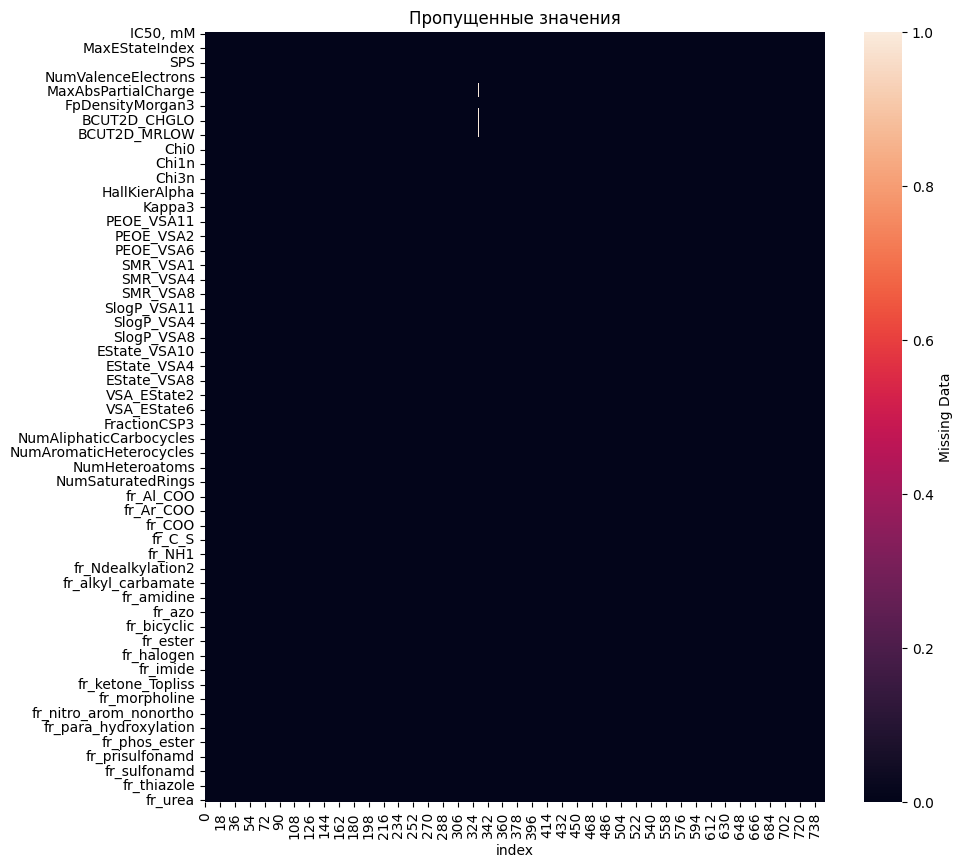

In [10]:
plt.figure(figsize=(10,10))
plt.title("Пропущенные значения")
sns.heatmap(train_data.isna().transpose(),
            cbar_kws={'label': 'Missing Data'})

### Колонки

Нам даны числовые и булевы колонки

In [11]:
print(*zip(train_data.dtypes.index, train_data.dtypes), sep="\n")

('IC50, mM', dtype('float64'))
('CC50, mM', dtype('float64'))
('SI', dtype('float64'))
('MaxAbsEStateIndex', dtype('float64'))
('MaxEStateIndex', dtype('float64'))
('MinAbsEStateIndex', dtype('float64'))
('MinEStateIndex', dtype('float64'))
('qed', dtype('float64'))
('SPS', dtype('float64'))
('MolWt', dtype('float64'))
('HeavyAtomMolWt', dtype('float64'))
('ExactMolWt', dtype('float64'))
('NumValenceElectrons', dtype('int64'))
('NumRadicalElectrons', dtype('int64'))
('MaxPartialCharge', dtype('float64'))
('MinPartialCharge', dtype('float64'))
('MaxAbsPartialCharge', dtype('float64'))
('MinAbsPartialCharge', dtype('float64'))
('FpDensityMorgan1', dtype('float64'))
('FpDensityMorgan2', dtype('float64'))
('FpDensityMorgan3', dtype('float64'))
('BCUT2D_MWHI', dtype('float64'))
('BCUT2D_MWLOW', dtype('float64'))
('BCUT2D_CHGHI', dtype('float64'))
('BCUT2D_CHGLO', dtype('float64'))
('BCUT2D_LOGPHI', dtype('float64'))
('BCUT2D_LOGPLOW', dtype('float64'))
('BCUT2D_MRHI', dtype('float64'))
('BC

### Распределение таргета

SI = IC50 / CC50

У таргета очень длинный хвост...

In [13]:
train_data[target].describe()

,"IC50, mM","CC50, mM",SI
count,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313
std,370.367937,641.515163,788.882198
min,0.003517,0.700808,0.011489
25%,13.222351,99.998894,1.500000
50%,44.069306,376.580899,4.000000
75%,206.787402,877.508784,17.372463
max,4095.188563,4538.976189,15620.600000


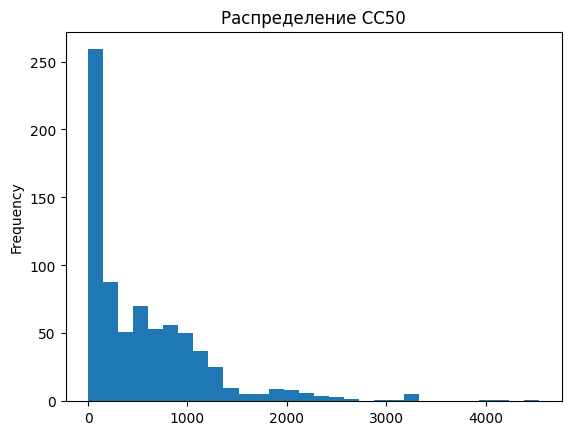

In [16]:
plt.title("Распределение CC50")
train_data["CC50, mM"].plot.hist(bins=30)
plt.show()

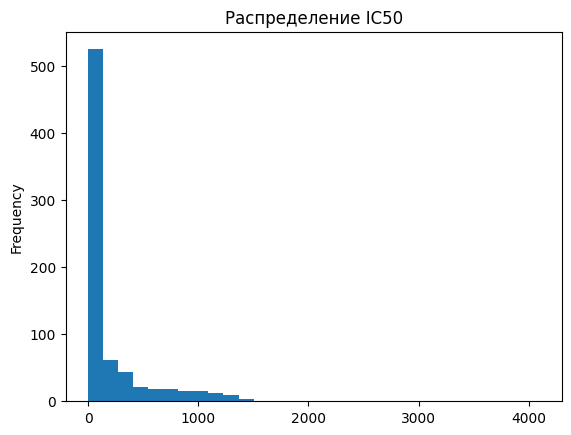

In [17]:
plt.title("Распределение IC50")
train_data["IC50, mM"].plot.hist(bins=30)
plt.show()

#### Распределение SI

Так как у SI особенно длинный хвост, его решили логарифмировать

Почему выбрали log10(x + 10) -- так как получали распределение, наиболее близкое к распределению двух других таргетов. Раз уж мы используем один конвейер для всех данных, давайте хотя бы данные к единому виду приведем

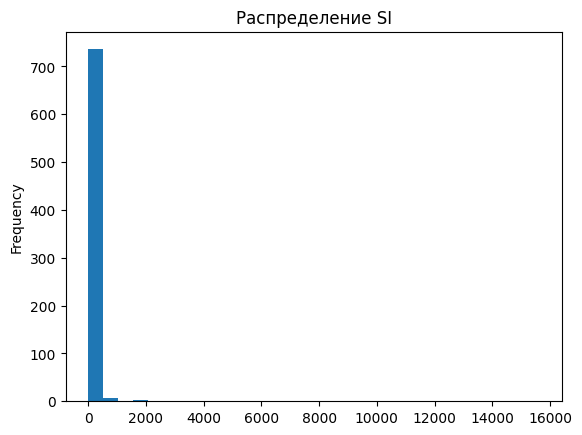

In [23]:
plt.title("Распределение SI")
train_data["SI"].plot.hist(bins=30)
plt.show()

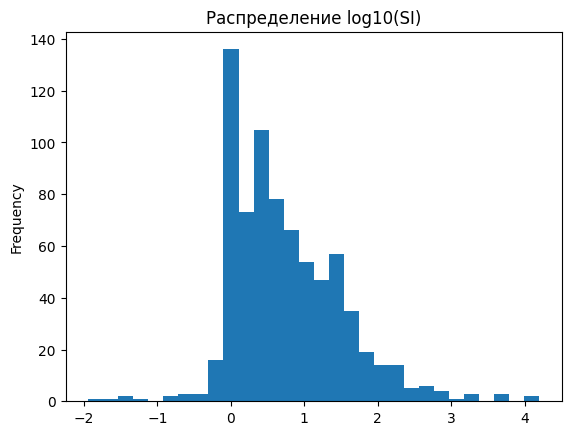

In [24]:
plt.title("Распределение log10(SI)")
pd.Series(np.log10(train_data["SI"])).plot.hist(bins=30)
plt.show()

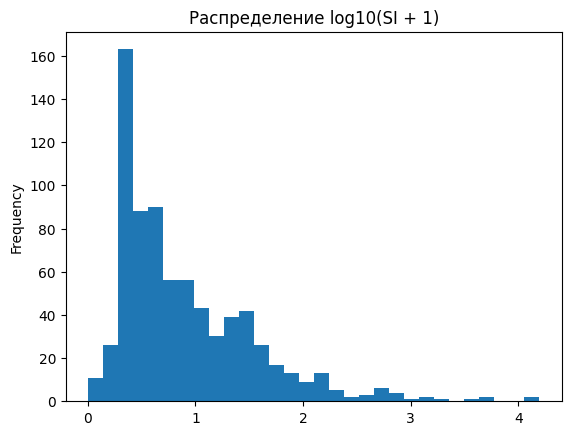

In [25]:
plt.title("Распределение log10(SI + 1)")
pd.Series(np.log10(train_data["SI"] + 1)).plot.hist(bins=30)
plt.show()

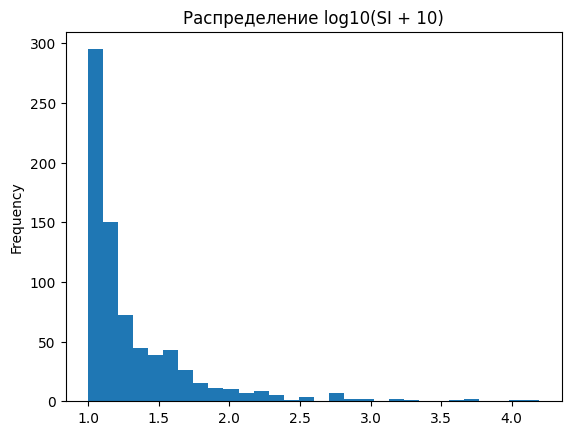

In [26]:
plt.title("Распределение log10(SI + 10)")
pd.Series(np.log10(train_data["SI"] + 10)).plot.hist(bins=30)
plt.show()

### Корреляция

Матрица корреляции огромна, проще посмотреть, где корреляция с таргетами выше 0.3

In [14]:
total_corr = train_data.corr()
total_corr

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
"IC50, mM",1.000000,0.470444,-0.060518,0.106600,0.106600,-0.100622,-0.179369,0.106424,-0.042822,-0.142172,...,-0.071692,0.047173,0.026526,0.022097,0.071937,-0.075119,NaN,0.012712,-0.037690,-0.018650
"CC50, mM",0.470444,1.000000,-0.005702,-0.109807,-0.109807,0.091942,0.058514,0.118275,0.126362,-0.305003,...,-0.102930,-0.032918,-0.006899,0.022078,0.020293,-0.062283,NaN,-0.045844,-0.025132,0.086926
SI,-0.060518,-0.005702,1.000000,0.007973,0.007973,-0.062446,0.025656,0.044350,-0.008016,-0.047341,...,-0.020821,0.004861,-0.008868,-0.004025,-0.004083,-0.023675,NaN,-0.025742,-0.008372,-0.004550
MaxAbsEStateIndex,0.106600,-0.109807,0.007973,1.000000,1.000000,-0.665456,-0.524071,-0.182104,-0.422414,0.417940,...,-0.021127,0.061740,0.055508,-0.061082,0.012998,0.140735,NaN,0.112062,-0.204855,0.025937
MaxEStateIndex,0.106600,-0.109807,0.007973,1.000000,1.000000,-0.665456,-0.524071,-0.182104,-0.422414,0.417940,...,-0.021127,0.061740,0.055508,-0.061082,0.012998,0.140735,NaN,0.112062,-0.204855,0.025937
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fr_thiazole,-0.075119,-0.062283,-0.023675,0.140735,0.140735,-0.094989,0.044017,-0.287635,-0.154079,0.365305,...,0.079816,-0.027916,-0.024935,-0.008775,-0.008775,1.000000,NaN,0.142245,-0.035737,-0.019673
fr_thiocyan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fr_thiophene,0.012712,-0.045844,-0.025742,0.112062,0.112062,-0.136306,0.089248,0.028663,-0.050855,0.131868,...,-0.056034,-0.031685,-0.028302,-0.009959,-0.009959,0.142245,NaN,1.000000,-0.040562,-0.022329
fr_unbrch_alkane,-0.037690,-0.025132,-0.008372,-0.204855,-0.204855,0.260849,0.098514,-0.240805,0.021889,0.194217,...,-0.030553,-0.017276,-0.015432,-0.005430,-0.005430,-0.035737,NaN,-0.040562,1.000000,-0.012175


In [15]:
for col in total_corr.drop(columns=target).columns:
    for t_col in target:
        if abs(total_corr.loc[col, t_col]) > 0.3:
            print(col, t_col, total_corr.loc[col, t_col])

MolWt CC50, mM -0.30500341044396384
HeavyAtomMolWt CC50, mM -0.3015906292055266
ExactMolWt CC50, mM -0.30497730282153007
NumValenceElectrons CC50, mM -0.302281289652276
Chi0 CC50, mM -0.3050920890211949
Chi1 CC50, mM -0.3024015714965455
Chi1v CC50, mM -0.30039804564304406
Kappa1 CC50, mM -0.30482491947742296
Kappa2 CC50, mM -0.3028234941276657
LabuteASA CC50, mM -0.306633726993619
HeavyAtomCount CC50, mM -0.30382308357282506
MolMR CC50, mM -0.3066210053382458


## "Бесполезные" фичи

Нам дан небольшой датасет, в нем есть константные и одинаковые колонки

In [29]:
for col in train_data.columns:
    unique_val = len(train_data[col].unique())
    if unique_val == 1:
        print(f"Column {col} has no unique features!")

Column NumRadicalElectrons has no unique features!
Column SMR_VSA8 has no unique features!
Column SlogP_VSA9 has no unique features!
Column fr_N_O has no unique features!
Column fr_SH has no unique features!
Column fr_azide has no unique features!
Column fr_barbitur has no unique features!
Column fr_benzodiazepine has no unique features!
Column fr_diazo has no unique features!
Column fr_dihydropyridine has no unique features!
Column fr_isocyan has no unique features!
Column fr_isothiocyan has no unique features!
Column fr_lactam has no unique features!
Column fr_nitroso has no unique features!
Column fr_phos_acid has no unique features!
Column fr_phos_ester has no unique features!
Column fr_prisulfonamd has no unique features!
Column fr_thiocyan has no unique features!


In [30]:
for i in range(len(train_data.columns) - 1):
    for j in range(i + 1, len(train_data.columns)):
        if (train_data[train_data.columns[i]] != train_data[train_data.columns[j]]).sum() == 0:
            print(f"Columns {train_data.columns[i]} and {train_data.columns[j]} are the same!")


Columns MaxAbsEStateIndex and MaxEStateIndex are the same!
Columns NumRadicalElectrons and SMR_VSA8 are the same!
Columns NumRadicalElectrons and SlogP_VSA9 are the same!
Columns NumRadicalElectrons and fr_N_O are the same!
Columns NumRadicalElectrons and fr_SH are the same!
Columns NumRadicalElectrons and fr_azide are the same!
Columns NumRadicalElectrons and fr_barbitur are the same!
Columns NumRadicalElectrons and fr_benzodiazepine are the same!
Columns NumRadicalElectrons and fr_diazo are the same!
Columns NumRadicalElectrons and fr_dihydropyridine are the same!
Columns NumRadicalElectrons and fr_isocyan are the same!
Columns NumRadicalElectrons and fr_isothiocyan are the same!
Columns NumRadicalElectrons and fr_lactam are the same!
Columns NumRadicalElectrons and fr_nitroso are the same!
Columns NumRadicalElectrons and fr_phos_acid are the same!
Columns NumRadicalElectrons and fr_phos_ester are the same!
Columns NumRadicalElectrons and fr_prisulfonamd are the same!
Columns NumRadi

### Самое странное: кажется, что у нас есть одинаковый таргет

Мне не нравится диагональная линия на scatterplot

<Axes: xlabel='CC50, mM', ylabel='IC50, mM'>

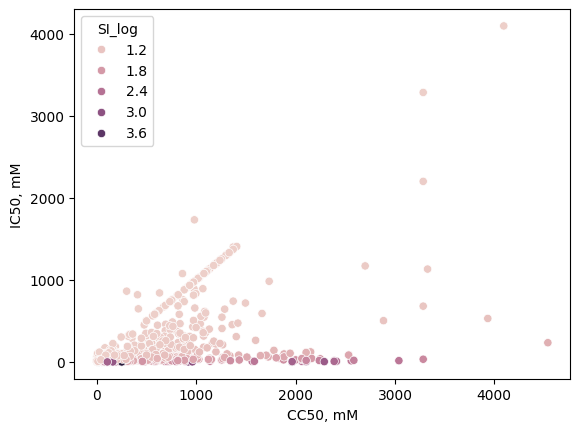

In [34]:
tmp_data = train_data[["IC50, mM", "CC50, mM", "SI"]]
tmp_data["SI_log"] = np.log10(10 + tmp_data["SI"])
sns.scatterplot(y="IC50, mM", x="CC50, mM", data=tmp_data, hue="SI_log")